# arc1withgen-aug-1000 visualization

`data/arc1withgen-aug-1000` の ARC example を可視化します。`GROUP_ID` と `PUZZLE_ID` を指定し、該当 puzzle 内の example はランダムに 1 つ選びます。

In [ ]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

DATASET_DIR = Path("data/arc1withgen-aug-1000")

# ここを変更してください
SPLIT = "train"        # "train" or "test"
GROUP_ID = 1           # 0-based group id
PUZZLE_ID = 0          # group 内 local puzzle id。PUZZLE_ID_MODE="absolute" なら split 全体の puzzle index
PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
NUM_EXAMPLES = 10       # 表示するランダム example 数
RANDOM_SEED = None     # None なら毎回ランダム。整数なら再現可能


In [2]:
ARC_TOKEN_PAD = 0
ARC_TOKEN_EOS = 1
ARC_TOKEN_COLOR_OFFSET = 2
ARC_NUM_COLORS = 10

ARC_COLORS = [
    "#000000",  # 0 black
    "#0074D9",  # 1 blue
    "#FF4136",  # 2 red
    "#2ECC40",  # 3 green
    "#FFDC00",  # 4 yellow
    "#AAAAAA",  # 5 gray
    "#F012BE",  # 6 magenta
    "#FF851B",  # 7 orange
    "#7FDBFF",  # 8 cyan
    "#870C25",  # 9 dark red
]
ARC_CMAP = ListedColormap(ARC_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, ARC_NUM_COLORS + 0.5, 1.0), ARC_CMAP.N)


def load_split(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    with (split_dir / "dataset.json").open() as f:
        metadata = json.load(f)

    data = {
        "split": split,
        "metadata": metadata,
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "seq_offsets": np.load(split_dir / "all__seq_offsets.npy"),
        "label_seq_offsets": np.load(split_dir / "all__label_seq_offsets.npy"),
        "seq_shapes": np.load(split_dir / "all__seq_shapes.npy"),
        "label_seq_shapes": np.load(split_dir / "all__label_seq_shapes.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
    }

    examples_path = split_dir / "all__examples.npy"
    example_shapes_path = split_dir / "all__example_shapes.npy"
    if examples_path.exists() and example_shapes_path.exists():
        data["examples"] = np.load(examples_path, allow_pickle=True)
        data["example_shapes"] = np.load(example_shapes_path, allow_pickle=True)
    return data


def decode_arc_canvas(tokens, shape):
    canvas = np.asarray(tokens, dtype=np.uint8).reshape(tuple(int(x) for x in shape))

    nonzero_rows = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)

    active = canvas[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]

    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return (cropped.astype(np.int16) - ARC_TOKEN_COLOR_OFFSET).astype(np.uint8)


def render_grid(ax, grid, title):
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{grid.shape[0]}x{grid.shape[1]}", fontsize=11)
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#222222", linewidth=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.0)


def identifier_name(split_data, puzzle_index):
    with (DATASET_DIR / "identifiers.json").open() as f:
        identifiers = json.load(f)
    ident = int(split_data["puzzle_identifiers"][puzzle_index])
    return identifiers[ident] if 0 <= ident < len(identifiers) else f"<unknown:{ident}>"


In [3]:
def resolve_puzzle_index(split_data, group_id, puzzle_id, mode="local"):
    group_indices = split_data["group_indices"]
    if not (0 <= group_id < len(group_indices) - 1):
        raise IndexError(f"GROUP_ID={group_id} is out of range [0, {len(group_indices) - 2}]")

    group_start = int(group_indices[group_id])
    group_end = int(group_indices[group_id + 1])
    group_size = group_end - group_start

    if mode == "local":
        if not (0 <= puzzle_id < group_size):
            raise IndexError(f"local PUZZLE_ID={puzzle_id} is out of range [0, {group_size - 1}] for group {group_id}")
        return group_start + int(puzzle_id)

    if mode == "absolute":
        if not (group_start <= puzzle_id < group_end):
            raise IndexError(f"absolute PUZZLE_ID={puzzle_id} is not in group {group_id}; valid [{group_start}, {group_end - 1}]")
        return int(puzzle_id)

    if mode == "auto":
        if group_start <= puzzle_id < group_end:
            return int(puzzle_id)
        if 0 <= puzzle_id < group_size:
            return group_start + int(puzzle_id)
        raise IndexError(
            f"PUZZLE_ID={puzzle_id} is neither a local id [0, {group_size - 1}] nor an absolute id [{group_start}, {group_end - 1}]"
        )

    raise ValueError('PUZZLE_ID_MODE must be "local", "absolute", or "auto"')


def choose_random_example_indices(split_data, puzzle_index, num_examples=1, seed=None):
    puzzle_indices = split_data["puzzle_indices"]
    start = int(puzzle_indices[puzzle_index])
    end = int(puzzle_indices[puzzle_index + 1])
    if start >= end:
        raise ValueError(f"puzzle_index={puzzle_index} has no examples")
    num_examples = max(1, int(num_examples))
    rng = random.Random(seed)
    population = list(range(start, end))
    if num_examples <= len(population):
        return rng.sample(population, num_examples)
    return [rng.choice(population) for _ in range(num_examples)]


def load_example_pair(split_data, example_index):
    in_start = int(split_data["seq_offsets"][example_index])
    in_end = int(split_data["seq_offsets"][example_index + 1])
    label_start = int(split_data["label_seq_offsets"][example_index])
    label_end = int(split_data["label_seq_offsets"][example_index + 1])

    input_shape = split_data["seq_shapes"][example_index]
    output_shape = split_data["label_seq_shapes"][example_index]

    inputs = split_data["inputs"][in_start:in_end]
    labels = split_data["labels"][label_start:label_end]

    input_grid = decode_arc_canvas(inputs, input_shape)
    output_grid = decode_arc_canvas(labels, output_shape)
    return input_grid, output_grid


def load_context_pairs_if_available(split_data, example_index):
    if "examples" not in split_data:
        return []

    context = split_data["examples"][example_index]
    context_shapes = split_data["example_shapes"][example_index]
    pairs = []
    for i in range(len(context)):
        inp = decode_arc_canvas(context[i][0], context_shapes[i][0])
        out = decode_arc_canvas(context[i][1], context_shapes[i][1])
        pairs.append((inp, out))
    return pairs


In [4]:
split_data = load_split(DATASET_DIR, SPLIT)
puzzle_index = resolve_puzzle_index(split_data, GROUP_ID, PUZZLE_ID, PUZZLE_ID_MODE)
example_indices = choose_random_example_indices(split_data, puzzle_index, NUM_EXAMPLES, RANDOM_SEED)

group_start = int(split_data["group_indices"][GROUP_ID])
group_end = int(split_data["group_indices"][GROUP_ID + 1])
puzzle_start = int(split_data["puzzle_indices"][puzzle_index])
puzzle_end = int(split_data["puzzle_indices"][puzzle_index + 1])

print(f"dataset: {DATASET_DIR}")
print(f"split: {SPLIT}")
print(f"group_id: {GROUP_ID}  puzzle range: [{group_start}, {group_end - 1}]  group size: {group_end - group_start}")
print(f"puzzle_index: {puzzle_index}  local puzzle id: {puzzle_index - group_start}")
print(f"puzzle identifier: {identifier_name(split_data, puzzle_index)}")
print(f"selected examples: {example_indices}")
print("local example ids:", [idx - puzzle_start for idx in example_indices], f"/ {puzzle_end - puzzle_start - 1}")


IndexError: local PUZZLE_ID=4100 is out of range [0, 71] for group 0

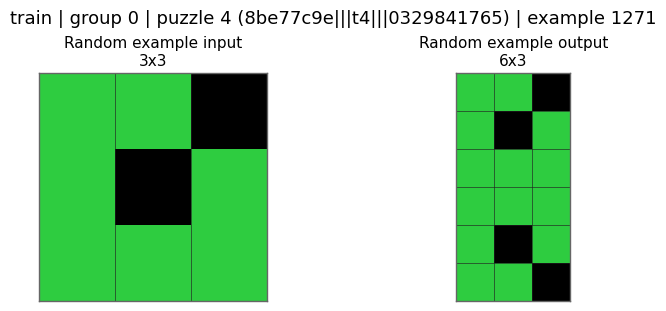

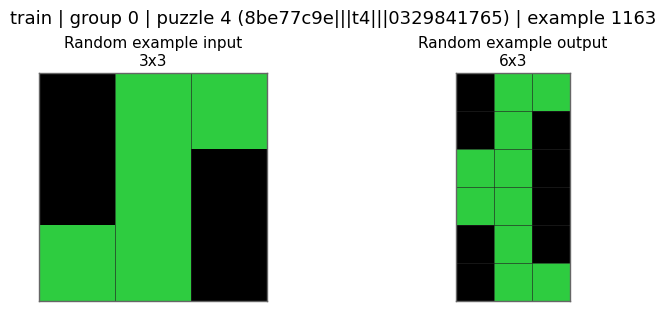

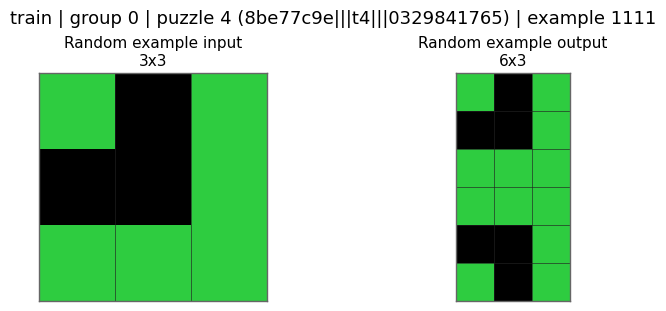

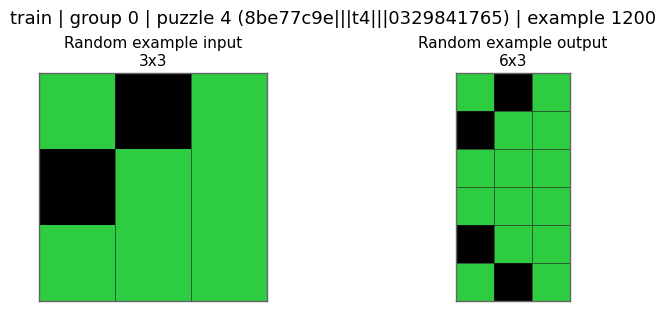

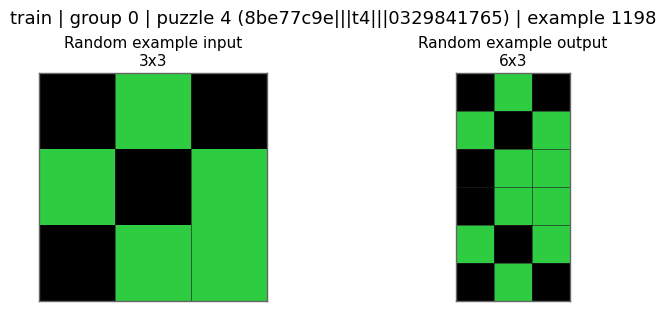

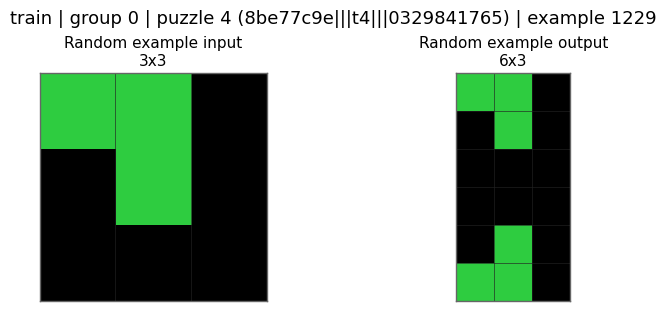

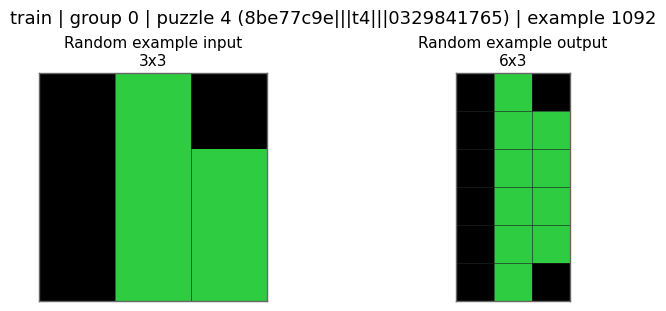

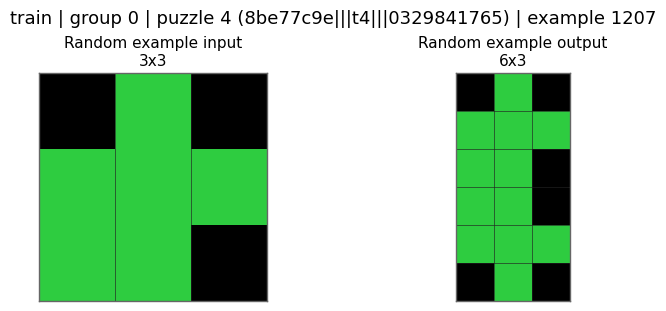

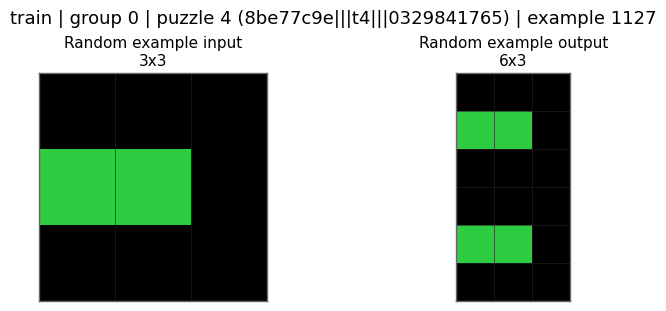

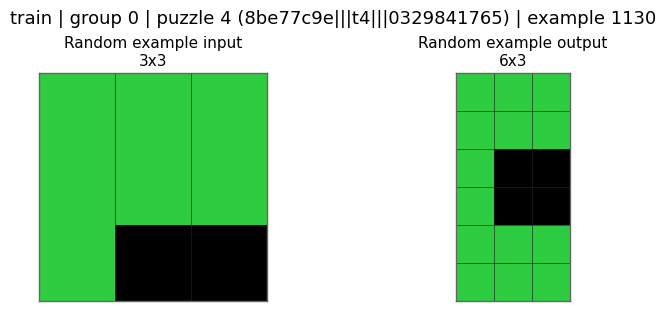

In [ ]:
for example_index in example_indices:
    context_pairs = load_context_pairs_if_available(split_data, example_index)
    target_input, target_output = load_example_pair(split_data, example_index)

    rows = len(context_pairs) + 1
    fig, axes = plt.subplots(rows, 2, figsize=(7.2, max(3.0, 2.9 * rows)), squeeze=False, constrained_layout=True)

    for row, (inp, out) in enumerate(context_pairs):
        render_grid(axes[row, 0], inp, f"Context {row} input")
        render_grid(axes[row, 1], out, f"Context {row} output")

    render_grid(axes[-1, 0], target_input, "Random example input")
    render_grid(axes[-1, 1], target_output, "Random example output")

    title = (
        f"{SPLIT} | group {GROUP_ID} | puzzle {puzzle_index} "
        f"({identifier_name(split_data, puzzle_index)}) | example {example_index}"
    )
    fig.suptitle(title, fontsize=13)
    plt.show()


## Test split の表示

`test` split を表示する専用セルです。`TEST_GROUP_ID` と `TEST_PUZZLE_ID` を指定してください。

dataset: data/arc1withgen-aug-1000
split: test
group_id: 0  puzzle range: [0, 999]  group size: 1000
puzzle_index: 0  local puzzle id: 0
puzzle identifier: 1e81d6f9
selected examples: [0]
local example ids: [0] / 0


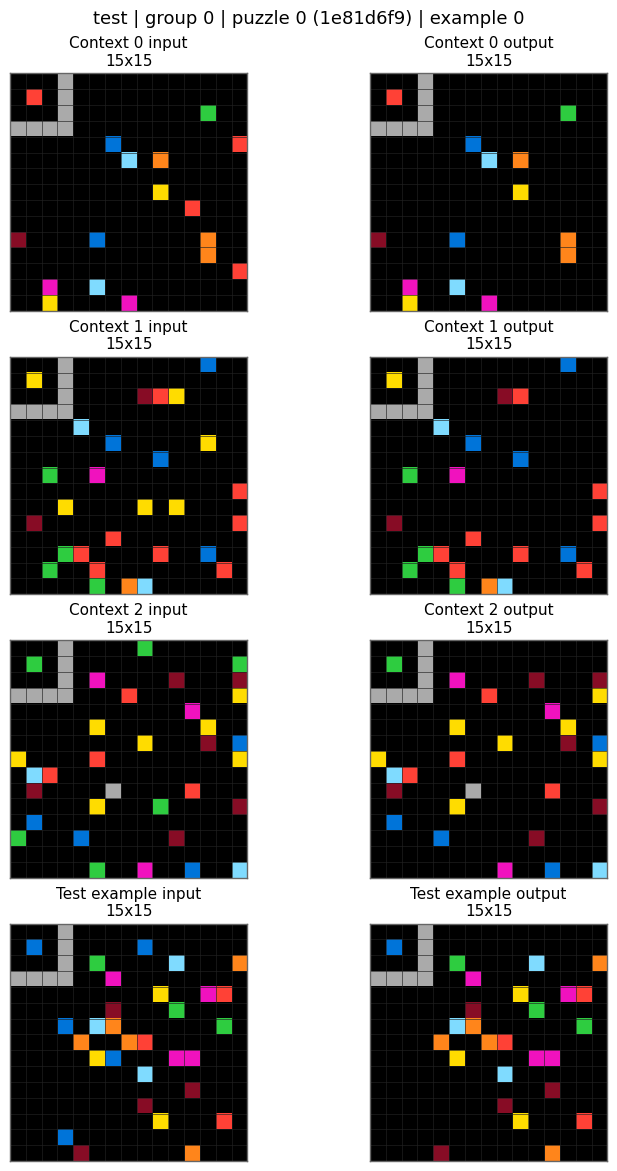

In [ ]:
TEST_GROUP_ID = 0
TEST_PUZZLE_ID = 0
TEST_PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
TEST_NUM_EXAMPLES = 1
TEST_RANDOM_SEED = None

test_data = load_split(DATASET_DIR, "test")
test_puzzle_index = resolve_puzzle_index(test_data, TEST_GROUP_ID, TEST_PUZZLE_ID, TEST_PUZZLE_ID_MODE)
test_example_indices = choose_random_example_indices(
    test_data,
    test_puzzle_index,
    TEST_NUM_EXAMPLES,
    TEST_RANDOM_SEED,
)

test_group_start = int(test_data["group_indices"][TEST_GROUP_ID])
test_group_end = int(test_data["group_indices"][TEST_GROUP_ID + 1])
test_puzzle_start = int(test_data["puzzle_indices"][test_puzzle_index])
test_puzzle_end = int(test_data["puzzle_indices"][test_puzzle_index + 1])

print(f"dataset: {DATASET_DIR}")
print("split: test")
print(f"group_id: {TEST_GROUP_ID}  puzzle range: [{test_group_start}, {test_group_end - 1}]  group size: {test_group_end - test_group_start}")
print(f"puzzle_index: {test_puzzle_index}  local puzzle id: {test_puzzle_index - test_group_start}")
print(f"puzzle identifier: {identifier_name(test_data, test_puzzle_index)}")
print(f"selected examples: {test_example_indices}")
print("local example ids:", [idx - test_puzzle_start for idx in test_example_indices], f"/ {test_puzzle_end - test_puzzle_start - 1}")

for example_index in test_example_indices:
    context_pairs = load_context_pairs_if_available(test_data, example_index)
    target_input, target_output = load_example_pair(test_data, example_index)

    rows = len(context_pairs) + 1
    fig, axes = plt.subplots(rows, 2, figsize=(7.2, max(3.0, 2.9 * rows)), squeeze=False, constrained_layout=True)

    for row, (inp, out) in enumerate(context_pairs):
        render_grid(axes[row, 0], inp, f"Context {row} input")
        render_grid(axes[row, 1], out, f"Context {row} output")

    render_grid(axes[-1, 0], target_input, "Test example input")
    render_grid(axes[-1, 1], target_output, "Test example output")

    title = (
        f"test | group {TEST_GROUP_ID} | puzzle {test_puzzle_index} "
        f"({identifier_name(test_data, test_puzzle_index)}) | example {example_index}"
    )
    fig.suptitle(title, fontsize=13)
    plt.show()


## Optional: group / puzzle の一覧

大きな group で puzzle id を探すときに使ってください。

In [ ]:
def list_puzzles_in_group(split="train", group_id=0, max_rows=20):
    split_data = load_split(DATASET_DIR, split)
    group_start = int(split_data["group_indices"][group_id])
    group_end = int(split_data["group_indices"][group_id + 1])
    print(f"split={split} group={group_id} puzzles={group_end - group_start}")
    for puzzle_index in range(group_start, min(group_end, group_start + max_rows)):
        start = int(split_data["puzzle_indices"][puzzle_index])
        end = int(split_data["puzzle_indices"][puzzle_index + 1])
        print(
            f"local={puzzle_index - group_start:4d}  absolute={puzzle_index:7d}  "
            f"examples={end - start:4d}  id={identifier_name(split_data, puzzle_index)}"
        )


list_puzzles_in_group(SPLIT, GROUP_ID, max_rows=20)


split=train group=0 puzzles=72
local=   0  absolute=      0  examples= 266  id=8be77c9e
local=   1  absolute=      1  examples= 266  id=8be77c9e|||t7|||0612397845
local=   2  absolute=      2  examples= 266  id=8be77c9e|||t7|||0821593764
local=   3  absolute=      3  examples= 266  id=8be77c9e|||t3|||0856249713
local=   4  absolute=      4  examples= 266  id=8be77c9e|||t4|||0329841765
local=   5  absolute=      5  examples= 266  id=8be77c9e|||t1|||0835496271
local=   6  absolute=      6  examples= 266  id=8be77c9e|||t1|||0497281653
local=   7  absolute=      7  examples= 266  id=8be77c9e|||t0|||0831762954
local=   8  absolute=      8  examples= 266  id=8be77c9e|||t3|||0394725861
local=   9  absolute=      9  examples= 266  id=8be77c9e|||t3|||0185369742
local=  10  absolute=     10  examples= 266  id=8be77c9e|||t0|||0673124958
local=  11  absolute=     11  examples= 266  id=8be77c9e|||t7|||0978561432
local=  12  absolute=     12  examples= 266  id=8be77c9e|||t4|||0657492813
local=  13  